# Lab 1 Part 2

### Python / Google Colab

This practical introduces graphical data exploration in Python. We use **pandas** to organise data, **matplotlib** and **seaborn** to create static graphics, and **plotly** for an interactive map.



### Learning outcomes
By the end of the practical, you should be able to:

- inspect a dataset before analysis;
- choose a suitable graph for categorical, quantitative, temporal and spatial data;
- produce bar charts, pie charts, histograms, box plots, scatter plots and line plots;
- customise labels, colours and plotting symbols;
- split a graph into separate panels using faceting;
- explain what a graph reveals about a dataset.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Preliminaries

Run the cell below to load the required libraries. These libraries are already available in a standard Google Colab environment.


In [3]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)


## 2. Data

We use the `mtcars` dataset, which contains fuel consumption and design characteristics for 32 cars from the 1973–74 *Motor Trend* magazine. The data are embedded below as CSV text, replacing the R-specific `data(mtcars)` and avoiding an external dependency.


In [4]:
mtcars_csv = """model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4
Merc 280C,17.8,6,167.6,123,3.92,3.440,18.90,1,0,4,4
Merc 450SE,16.4,8,275.8,180,3.07,4.070,17.40,0,0,3,3
Merc 450SL,17.3,8,275.8,180,3.07,3.730,17.60,0,0,3,3
Merc 450SLC,15.2,8,275.8,180,3.07,3.780,18.00,0,0,3,3
Cadillac Fleetwood,10.4,8,472.0,205,2.93,5.250,17.98,0,0,3,4
Lincoln Continental,10.4,8,460.0,215,3.00,5.424,17.82,0,0,3,4
Chrysler Imperial,14.7,8,440.0,230,3.23,5.345,17.42,0,0,3,4
Fiat 128,32.4,4,78.7,66,4.08,2.200,19.47,1,1,4,1
Honda Civic,30.4,4,75.7,52,4.93,1.615,18.52,1,1,4,2
Toyota Corolla,33.9,4,71.1,65,4.22,1.835,19.90,1,1,4,1
Toyota Corona,21.5,4,120.1,97,3.70,2.465,20.01,1,0,3,1
Dodge Challenger,15.5,8,318.0,150,2.76,3.520,16.87,0,0,3,2
AMC Javelin,15.2,8,304.0,150,3.15,3.435,17.30,0,0,3,2
Camaro Z28,13.3,8,350.0,245,3.73,3.840,15.41,0,0,3,4
Pontiac Firebird,19.2,8,400.0,175,3.08,3.845,17.05,0,0,3,2
Fiat X1-9,27.3,4,79.0,66,4.08,1.935,18.90,1,1,4,1
Porsche 914-2,26.0,4,120.3,91,4.43,2.140,16.70,0,1,5,2
Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.90,1,1,5,2
Ford Pantera L,15.8,8,351.0,264,4.22,3.170,14.50,0,1,5,4
Ferrari Dino,19.7,6,145.0,175,3.62,2.770,15.50,0,1,5,6
Maserati Bora,15.0,8,301.0,335,3.54,3.570,14.60,0,1,5,8
Volvo 142E,21.4,4,121.0,109,4.11,2.780,18.60,1,1,4,2
"""




,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


Before plotting, examine the structure and quality of the data. Check dimensions, variable types, summary statistics and missing values.


In [6]:
mtcars = pd.read_csv("/content/drive/MyDrive/Stuff/mtcars.csv")

mtcars.head(7)

,manufacturer,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4


In [3]:
print(f"Rows: {mtcars.shape[0]}, columns: {mtcars.shape[1]}")
display(mtcars.dtypes.to_frame("data type"))
display(mtcars.describe().T)
display(mtcars.isna().sum().to_frame("missing values"))


Rows: 32, columns: 12


,data type
model,object
mpg,float64
cyl,int64
disp,float64
hp,int64
drat,float64
wt,float64
qsec,float64
vs,int64
am,int64


,count,mean,std,min,25%,50%,75%,max
mpg,32.0,20.090625,6.026948,10.400,15.42500,19.200,22.80,33.900
cyl,32.0,6.187500,1.785922,4.000,4.00000,6.000,8.00,8.000
disp,32.0,230.721875,123.938694,71.100,120.82500,196.300,326.00,472.000
hp,32.0,146.687500,68.562868,52.000,96.50000,123.000,180.00,335.000
drat,32.0,3.596563,0.534679,2.760,3.08000,3.695,3.92,4.930
wt,32.0,3.217250,0.978457,1.513,2.58125,3.325,3.61,5.424
qsec,32.0,17.848750,1.786943,14.500,16.89250,17.710,18.90,22.900
vs,32.0,0.437500,0.504016,0.000,0.00000,0.000,1.00,1.000
am,32.0,0.406250,0.498991,0.000,0.00000,0.000,1.00,1.000
gear,32.0,3.687500,0.737804,3.000,3.00000,4.000,4.00,5.000


,missing values
model,0
mpg,0
cyl,0
disp,0
hp,0
drat,0
wt,0
qsec,0
vs,0
am,0


## 3. Bar charts

Bar charts display frequencies for categorical variables. Here, we count cars with 4, 6 and 8 cylinders.


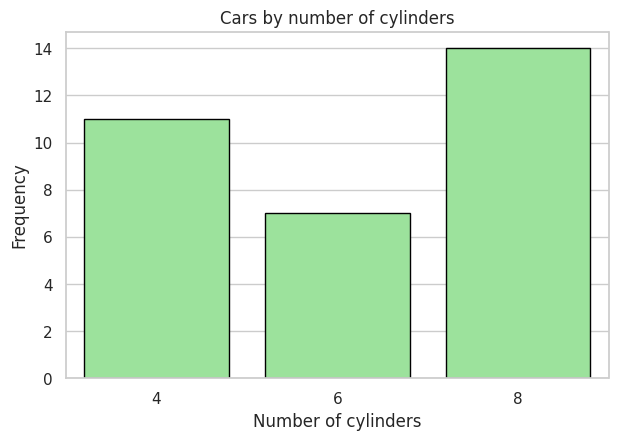

In [4]:
ax = sns.countplot(data=mtcars, x="cyl", color="lightgreen", edgecolor="black")
ax.set(xlabel="Number of cylinders", ylabel="Frequency", title="Cars by number of cylinders")
plt.show()


### Exercise 1
Create a bar chart showing the number of cars for each forward-gear category (`gear`). Add clear axis labels and a title.


In [ ]:
# Write your solution here


<details>
<summary><strong>Solution 1</strong></summary>

```python
ax = sns.countplot(data=mtcars, x="gear", color="steelblue", edgecolor="black")
ax.set(xlabel="Number of forward gears", ylabel="Frequency", title="Cars by gear category")
plt.show()
```
</details>


## 4. Pie charts

Pie charts show how a whole is divided into categories. They can become difficult to compare when there are many categories, so use them selectively.


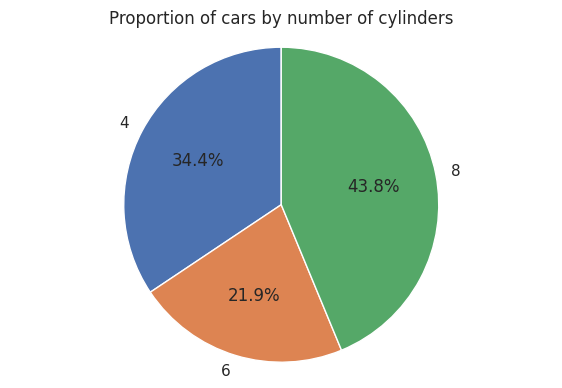

In [5]:
cylinder_counts = mtcars["cyl"].value_counts().sort_index()
plt.pie(cylinder_counts, labels=cylinder_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Proportion of cars by number of cylinders")
plt.axis("equal")
plt.show()


## 5. Histograms

Histograms display the distribution of a quantitative variable by grouping observations into intervals. Here, we examine fuel consumption in miles per gallon.


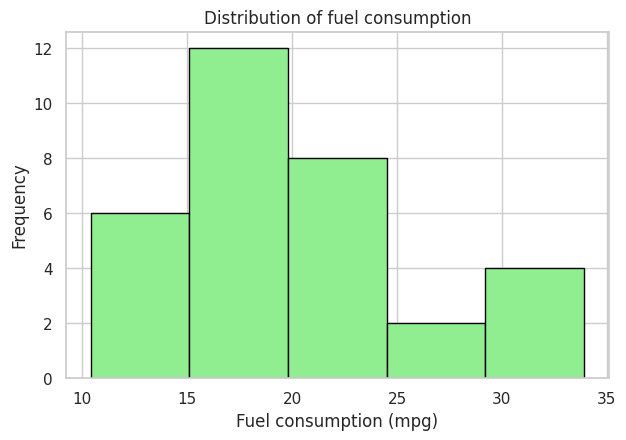

In [6]:
plt.hist(mtcars["mpg"], bins=5, color="lightgreen", edgecolor="black")
plt.xlabel("Fuel consumption (mpg)")
plt.ylabel("Frequency")
plt.title("Distribution of fuel consumption")
plt.show()


### Exercise 2
Draw a histogram of car weight (`wt`). Try two different numbers of bins. What feature of the distribution changes when the bin count changes?


In [ ]:
# Write your solution here


<details>
<summary><strong>Solution 2</strong></summary>

```python
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, bins in zip(axes, [5, 10]):
    ax.hist(mtcars["wt"], bins=bins, color="lightgreen", edgecolor="black")
    ax.set(title=f"Car weight: {bins} bins", xlabel="Weight (1,000 lb)", ylabel="Frequency")
plt.tight_layout()
plt.show()
```

The apparent smoothness and location of peaks can change with the bin width, even though the underlying observations are unchanged.
</details>


## 6. Box plots

Box plots summarise the median, quartiles and spread of a quantitative variable. Points beyond the whiskers indicate potential outliers under the box-plot rule. We compare fuel consumption between cylinder groups.


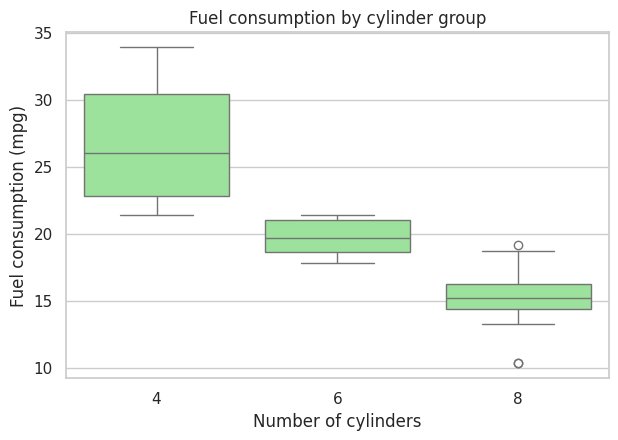

In [7]:
ax = sns.boxplot(data=mtcars, x="cyl", y="mpg", color="lightgreen")
ax.set(xlabel="Number of cylinders", ylabel="Fuel consumption (mpg)", title="Fuel consumption by cylinder group")
plt.show()


## 7. Scatter plots

Scatter plots display paired values of two quantitative variables and help reveal their association. Here, we compare car weight and fuel consumption.


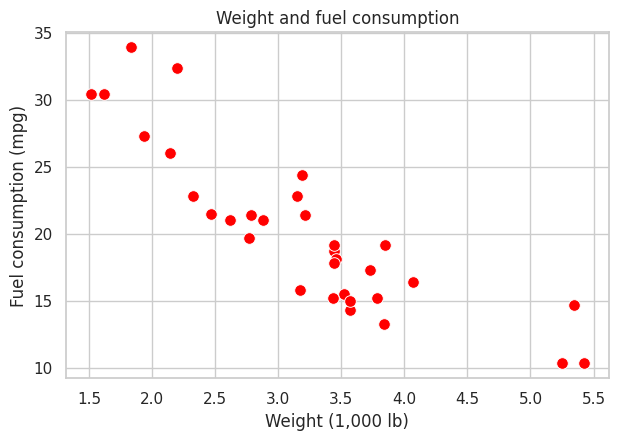

In [8]:
ax = sns.scatterplot(data=mtcars, x="wt", y="mpg", color="red", s=70)
ax.set(xlabel="Weight (1,000 lb)", ylabel="Fuel consumption (mpg)", title="Weight and fuel consumption")
plt.show()


The plot shows a negative association in this dataset: cars with greater weight tend to have lower miles per gallon.

### Customising the plot with colour
Colour can distinguish cylinder groups.


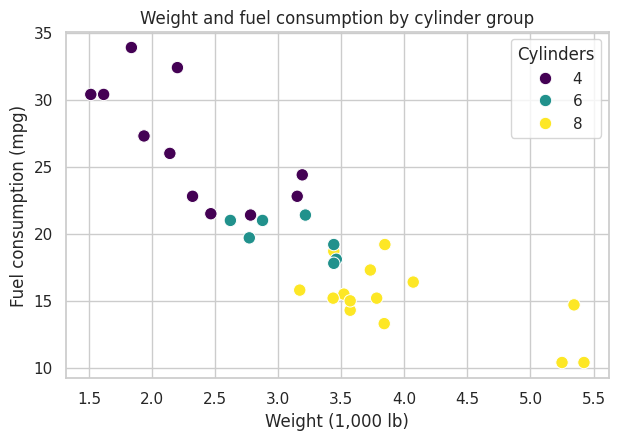

In [9]:
ax = sns.scatterplot(data=mtcars, x="wt", y="mpg", hue="cyl", palette="viridis", s=80)
ax.set(xlabel="Weight (1,000 lb)", ylabel="Fuel consumption (mpg)", title="Weight and fuel consumption by cylinder group")
ax.legend(title="Cylinders")
plt.show()


### Customising the plot with shape
When colour is unavailable or unsuitable, marker shape can distinguish groups.


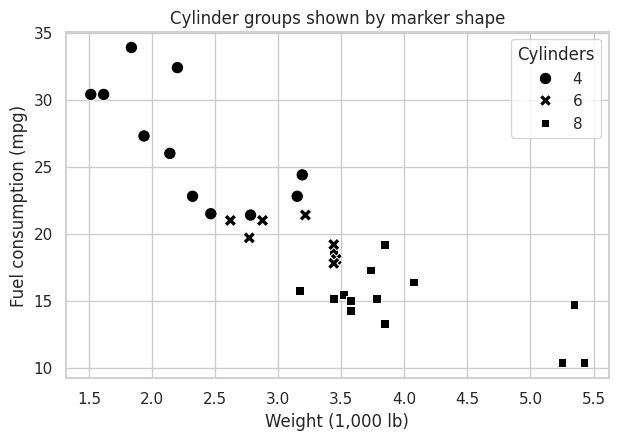

In [10]:
ax = sns.scatterplot(data=mtcars, x="wt", y="mpg", style="cyl", color="black", s=80)
ax.set(xlabel="Weight (1,000 lb)", ylabel="Fuel consumption (mpg)", title="Cylinder groups shown by marker shape")
ax.legend(title="Cylinders")
plt.show()


### Exercise 3
Create a scatter plot of horsepower (`hp`) against fuel consumption (`mpg`). Use colour to show transmission type, where `am = 0` is automatic and `am = 1` is manual.


In [ ]:
# Write your solution here


<details>
<summary><strong>Solution 3</strong></summary>

```python
plot_data = mtcars.assign(
    transmission=mtcars["am"].map({0: "Automatic", 1: "Manual"})
)
ax = sns.scatterplot(data=plot_data, x="hp", y="mpg", hue="transmission", s=80)
ax.set(xlabel="Horsepower", ylabel="Fuel consumption (mpg)", title="Horsepower and fuel consumption")
ax.legend(title="Transmission")
plt.show()
```
</details>


## 8. Faceting

Faceting separates groups into panels. This can expose patterns that are difficult to distinguish in a combined plot.


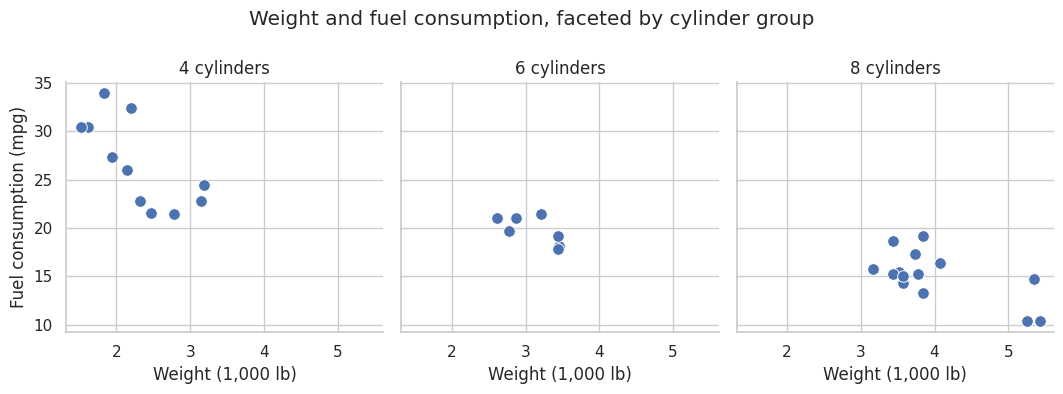

In [11]:
g = sns.FacetGrid(mtcars, col="cyl", height=4, aspect=0.9)
g.map_dataframe(sns.scatterplot, x="wt", y="mpg", s=70)
g.set_axis_labels("Weight (1,000 lb)", "Fuel consumption (mpg)")
g.set_titles("{col_name} cylinders")
g.fig.subplots_adjust(top=0.80)
g.fig.suptitle("Weight and fuel consumption, faceted by cylinder group")
plt.show()


## 9. Line plots

Line plots show values measured in an ordered sequence, commonly over time. The original practical uses R's `economics` dataset. To keep this notebook self-contained, the following cell creates a clearly labelled synthetic monthly series for demonstration; it is not the original `economics` data and must not be used for substantive analysis.


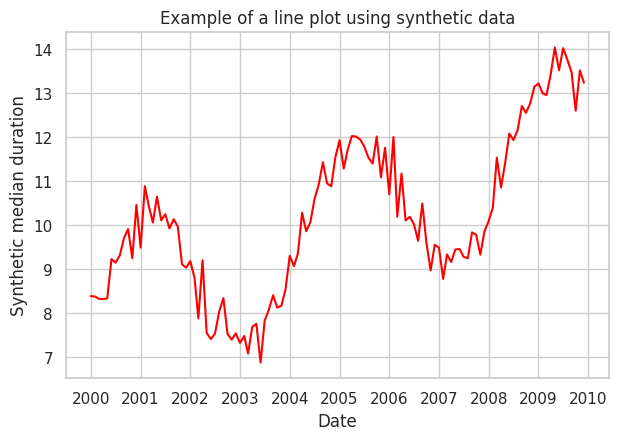

In [12]:
rng = np.random.default_rng(17)
dates = pd.date_range("2000-01-01", periods=120, freq="MS")
synthetic_economics = pd.DataFrame({
    "date": dates,
    "unemployment_duration": 8 + np.linspace(0, 4, len(dates)) + 1.8*np.sin(np.arange(len(dates))/8) + rng.normal(0, 0.35, len(dates))
})

ax = sns.lineplot(data=synthetic_economics, x="date", y="unemployment_duration", color="red")
ax.set(xlabel="Date", ylabel="Synthetic median duration", title="Example of a line plot using synthetic data")
plt.show()


### Exercise 4
Plot a six-month rolling mean of the synthetic series on the same chart as the original series.


In [ ]:
# Write your solution here


<details>
<summary><strong>Solution 4</strong></summary>

```python
line_data = synthetic_economics.copy()
line_data["rolling_mean"] = line_data["unemployment_duration"].rolling(6).mean()

plt.plot(line_data["date"], line_data["unemployment_duration"], alpha=0.5, label="Monthly value")
plt.plot(line_data["date"], line_data["rolling_mean"], linewidth=2, label="Six-month rolling mean")
plt.xlabel("Date")
plt.ylabel("Synthetic median duration")
plt.title("Monthly series and rolling mean")
plt.legend()
plt.show()
```
</details>


## 10. Maps

Maps display spatial variation. The R practical downloads detailed Mongolian administrative boundaries from GADM and attaches simulated regional values. The self-contained Python example below instead uses Plotly's country geometry to locate Mongolia and display a single demonstrative value. No claim about real conditions is intended.


In [13]:
map_data = pd.DataFrame({"iso_alpha": ["MNG"], "country": ["Mongolia"], "demonstration_value": [1]})
fig = px.choropleth(
    map_data,
    locations="iso_alpha",
    color="demonstration_value",
    hover_name="country",
    color_continuous_scale="Blues",
    title="Mongolia: country-level mapping demonstration"
)
fig.update_geos(fitbounds="locations", visible=True)
fig.update_layout(coloraxis_showscale=False)
fig.show()


## 11. Consolidation exercise

Choose **one quantitative outcome** (`mpg`, `hp`, `wt` or `qsec`) and **one grouping variable** (`cyl`, `gear`, `am` or `carb`). Produce a short exploratory analysis containing:

1. a data-quality check;
2. one distribution plot;
3. one grouped comparison;
4. one relationship plot;
5. two or three sentences interpreting only what the plots show.

Use informative titles, labels and units. Avoid causal language: these are observational data.


In [ ]:
# Build your consolidated analysis here


<details>
<summary><strong>Example solution</strong></summary>

```python
# Outcome: mpg; grouping variable: cyl
print(mtcars[["mpg", "cyl"]].isna().sum())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(data=mtcars, x="mpg", bins=8, ax=axes[0], color="lightgreen", edgecolor="black")
axes[0].set(title="Distribution of mpg", xlabel="Fuel consumption (mpg)")

sns.boxplot(data=mtcars, x="cyl", y="mpg", ax=axes[1], color="lightgreen")
axes[1].set(title="mpg by cylinder group", xlabel="Cylinders", ylabel="Fuel consumption (mpg)")

sns.scatterplot(data=mtcars, x="wt", y="mpg", hue="cyl", ax=axes[2], palette="viridis")
axes[2].set(title="Weight and mpg", xlabel="Weight (1,000 lb)", ylabel="Fuel consumption (mpg)")

plt.tight_layout()
plt.show()
```

Example interpretation: Fuel consumption varies across the 32 cars and is generally lower in the groups with more cylinders. In this dataset, greater weight is associated with lower miles per gallon, although the cylinder groups overlap.
</details>


## 12. Key messages

- Inspect data types, summaries and missing values before plotting.
- Match the graph to the variable type and analytical question.
- Labels and units are part of the analysis, not decoration.
- Different bin widths, scales and groupings can change how patterns appear.
- Visual association does not establish causation.
- Clearly label synthetic or simulated data.
